In [1]:
import numpy as np
import tensorflow as tf

2025-03-18 15:26:19.557807: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
tf.__version__

'2.12.0'

# About dataset

In [3]:
mnist = tf.keras.datasets.mnist

(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0

print("Train shape: ",x_train.shape, '\nTest shape: ', x_test.shape)
print("Train targets shape: ", y_train.shape, "\nTest targets shape: ", y_test.shape)

Train shape:  (60000, 28, 28) 
Test shape:  (10000, 28, 28)
Train targets shape:  (60000,) 
Test targets shape:  (10000,)


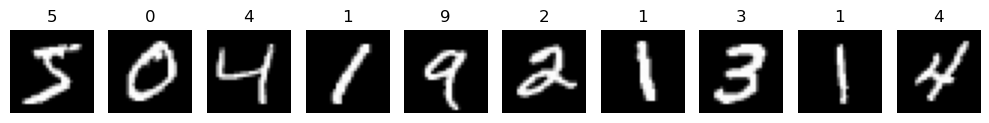

In [4]:
import matplotlib.pyplot as plt 

fig, axes = plt.subplots(1, 10, figsize=(10, 10))

for i in range(10):
    axes[i].imshow(x_train[i].reshape(28, 28), cmap="gray")
    axes[i].set_title(y_train[i])
    axes[i].axis('off')

plt.tight_layout()
plt.show()

# Classic realisation via tf

In [6]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(32, (3, 3), input_shape = (28, 28, 1)),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

model.fit(x_train, y_train, epochs = 5)

Epoch 1/5
1875/1875 [==============================] - 401s 213ms/step - loss: 0.2071 - accuracy: 0.9403
Epoch 2/5
1875/1875 [==============================] - 407s 217ms/step - loss: 0.0748 - accuracy: 0.9777
Epoch 3/5
1875/1875 [==============================] - 392s 209ms/step - loss: 0.0551 - accuracy: 0.9833
Epoch 4/5
1875/1875 [==============================] - 396s 211ms/step - loss: 0.0431 - accuracy: 0.9862
Epoch 5/5
1875/1875 [==============================] - 401s 214ms/step - loss: 0.0357 - accuracy: 0.9890


(maybe it is overfitting but it just an example)

# Realisation with NumPy

In [71]:
class Convolutional2D:
    def __init__(self, input_shape, kernel_size, depth, padding = 0, stride = 1):
        self.input_shape = input_shape
        self.kernel_size = kernel_size
        self.depth = depth
        self.padding = padding
        self.stride = stride

        self.w = np.random.randn(depth, input_shape[0], kernel_size, kernel_size) / 10
        self.b = np.zeros((depth, 1))

    def forward_prop(self, images_array):
        self.images_array = images_array
        if self.padding:
            arr = np.pad(self.images_array, pad_width=((0, 0), (self.padding, self.padding), (self.padding, self.padding)), mode='constant', constant_values=0)
        else:
            arr = self.images_array

        out_height = int((arr.shape[1] - self.kernel_size) / self.stride + 1)
        out_width = int((arr.shape[2] - self.kernel_size) / self.stride + 1)

        self.output_shape = (self.depth, out_height, out_width)
        
        result = np.zeros((self.depth, out_height, out_width))
        for i in range(self.depth):
            for j in range(0, out_height):
                for k in range(0, out_width):
                    current_window = arr[:, self.stride*j:self.stride*j + self.kernel_size, self.stride*k:self.stride*k + self.kernel_size]
                    result[i, j, k] = np.sum(current_window*self.w[i]) + self.b[i]
        return result

    def back_prop(self, grad_out, learning_rate = 0.01): #TODO
        grad_w = np.zeros_like(self.w)
        grad_b = np.zeros_like(self.b)
        grad_input = np.zeros_like(self.images_array)

        for i in range(self.depth):
            for j in range(self.output_shape[1]):
                for k in range(self.output_shape[2]):
                    d_w[i] += self.images_array[j*self.stride:j*self.stride + self.kernel_size, k*self.stride:k*self.stride + self.kernel_size] * grad_out[i, j, k]
                    d_b[i] += grad_out[i, j, k]

        for i in range(self.depth):
            for j in range(self.output_shape[1]):
                for k in range(self.output_shape[2]):
                    grad_input[j*self.stride:j*self.stride + self.kernel_size, k*self.stride:k*self.stride + self.kernel_size] += self.w[i] * grad_out[i, j, k]

        self.w -= learning_rate * grad_w
        self.b -= learning_rate * grad_b

        return grad_input
        

In [125]:
class MaxPooling2D:
    def __init__(self, filter_shape, stride):
        self.filter_shape = filter_shape
        self.stride = stride

    def forward_prop(self, images_array):
        self.images_array = images_array
        padding = 0
        out_height = int((self.images_array.shape[1] + 2 * padding - self.filter_shape) / self.stride + 1)
        out_width = int((self.images_array.shape[2] + 2 * padding - self.filter_shape) / self.stride + 1)

        result = np.zeros((out_height, out_width, self.images_array.shape[0])) # (out_height, out_width, depth)

        self.max_index = np.zeros((out_height, out_width, 2, self.images_array.shape[0]))  # max indices for each depth

        for d in range(self.images_array.shape[0]):
            for i in range(out_height):
                for j in range(out_width):
                    current_window = self.images_array[d, self.stride * i:self.stride * i + self.filter_shape, self.stride * j:self.stride * j + self.filter_shape]

                    max_val = np.max(current_window)
                    max_index = np.unravel_index(np.argmax(current_window), current_window.shape)

                    result[i, j, d] = max_val
                    self.max_index[i, j, :, d] = (self.stride * i + max_index[0], self.stride * j + max_index[1])

        return result

    def back_prop(self, grad_out):
        padding = 0
        grad_input = np.zeros_like(self.images_array)

        out_h, out_w, depth = grad_out.shape

        for d in range(depth):
            for i in range(out_h):
                for j in range(out_w):
                    max_index = self.max_index[i, j, :, d]
                    grad_input[d, max_index[0], max_index[1]] = grad_out[i, j, d]

        return grad_input

In [126]:
def flatten(img): #останется как есть вместо переписывания под целую функцию
    return img.flatten()

def sparse_crossentropy_loss(y, preds):
    log_preds = np.log(preds)
    loss = -np.sum(y*log_preds) / y.shape[0]

    return loss

def sparse_crossentropy_loss_backprop(y, preds):
    return preds - y #градиент

In [139]:
class Dense:
    def __init__(self, input_size, neurons, activation = 'relu'):
        self.neurons = neurons
        self.activation = activation
        
        rgen = np.random.RandomState(1)
        self.w = rgen.normal(loc=0.0, scale = 0.1, size=(input_size, neurons))
        self.b = np.zeros(neurons)

    def softmax_activation(self, z):
        return np.exp(z) / np.sum(np.exp(z), axis = 1, keepdims = True)

    def relu_activation(self, z):
        return np.maximum(0, z)
        
    def forward_prop(self, images_array):
        self.input = images_array
        self.z = np.dot(self.input, self.w) + self.b

        if self.activation == 'relu':
            self.a = self.relu_activation(self.z)
        else:
            self.a = self.softmax_activation(self.z)

        return self.a

    def back_prop(self, grad_out, learning_rate = 0.01): #TODO
        grad_z = sparse_crossentropy_loss_backprop(self.a, self.y_true)
        grad_w = np.dot(self.input.T, grad_z)
        grad_b = np.sum(grad_z)

        self.w -= learning_rate * grad_w
        self.b -= learning_rate * grad_b

        grad_input = np.dot(grad_z, self.w.T)

        return grad_input

In [140]:
conv_layer = Convolutional2D(input_shape = (1, 28, 28), kernel_size=3, depth = 5, padding=1, stride=1)
pool_layer = MaxPooling2D(filter_shape = 2, stride = 1)

In [142]:
x_total = x_train[:2000]

for e in range(7):
    for i in range(0, len(x_total), 50):
        x_batch = x_total[i:i+50]
        y_batch = x_train[i:i+50]

        output_conv = conv_layer.forward_prop(x_batch)
        output_pool = pool_layer.forward_prop(output_conv)
        output_pool_f = output_pool.flatten().reshape(output_pool.shape[0], -1)

        dense_layer = Dense(input_size = output_pool_f.shape[1], neurons=10, activation='softmax')        
        output_dense = dense_layer.forward_prop(output_pool_f)

        loss = sparse_crossentropy_loss(y_batch, output_dense)

        out_dense = output_dense - y_batch
        in_dense = dense_layer.back_prop(out_dense)
        in_pool = pool_layer.back_prop(in_dense)

        conv_layer.back_prop(in_pool)

        print(f"Эпоха {e + 1}, Значение функции потерь: {loss}")
        

ValueError: operands could not be broadcast together with shapes (50,28,28) (27,10) 